# Pipeline Anomaly Detection Demo

This notebook demonstrates a compact applied ML workflow for anomaly detection on pipeline-style operational data using **Isolation Forest** and **Random Forest**.

In [1]:
from anomaly_pipeline.feature_engineering import load_and_engineer_features
from anomaly_pipeline.model_training import (
    train_isolation_forest,
    train_random_forest,
)
from anomaly_pipeline.reporting import metrics_table
import matplotlib.pyplot as plt

In [2]:
df, X, y = load_and_engineer_features("../data/sample_pipeline_data.csv", short_window=5, long_window=12)
df.head()

,timestamp,pressure_psi,flow_rate_m3h,temperature_c,is_anomaly,anomaly_type,pressure_flow_ratio,hour_sin,hour_cos,pressure_diff,...,pressure_roll_std_5,pressure_zscore_12,flow_diff,flow_roll_mean_5,flow_roll_std_5,flow_zscore_12,temperature_diff,temperature_roll_mean_5,temperature_roll_std_5,temperature_zscore_12
0,2025-01-01 00:00:00,102.274,63.385,14.535,0,normal,1.613536,0.000000,1.000000,0.000,...,0.000000,0.000000,0.000,63.385000,0.000000,0.000000,0.000,14.5350,0.000000,0.000000
1,2025-01-01 01:00:00,102.099,64.734,15.477,0,normal,1.577208,0.258819,0.965926,-0.175,...,0.123744,0.000000,1.349,64.059500,0.953887,0.000000,0.942,15.0060,0.666095,0.000000
2,2025-01-01 02:00:00,104.675,60.294,14.475,0,normal,1.736077,0.500000,0.866025,2.576,...,1.439398,1.152565,-4.440,62.804333,2.276243,-1.102841,-1.002,14.8290,0.561986,-0.629909
3,2025-01-01 03:00:00,105.675,60.679,16.679,0,normal,1.741542,0.707107,0.707107,1.000,...,1.774490,1.123844,0.385,62.273000,2.140899,-0.744547,2.204,15.2915,1.032558,1.343750
4,2025-01-01 04:00:00,103.708,60.643,15.793,0,normal,1.710140,0.866025,0.500000,-1.967,...,1.536802,0.014185,-0.036,61.947000,1.992226,-0.654544,-0.886,15.3918,0.921918,0.435180


In [3]:
print(f"Rows: {len(df)}")
print(f"Anomaly rate: {y.mean():.3%}")

Rows: 720
Anomaly rate: 5.278%


## Isolation Forest

In [4]:
iso = train_isolation_forest(X, y)
iso.metrics

{'precision': 0.7272727272727273,
 'recall': 0.8421052631578947,
 'f1': 0.7804878048780488,
 'true_negative': 670,
 'false_positive': 12,
 'false_negative': 6,
 'true_positive': 32,
 'roc_auc': 0.9858388640222256,
 'average_precision': 0.7639344226266103}

## Random Forest baseline

In [5]:
rf = train_random_forest(X, y)
rf.metrics

{'precision': 1.0,
 'recall': 0.9736842105263158,
 'f1': 0.9866666666666667,
 'true_negative': 682,
 'false_positive': 0,
 'false_negative': 1,
 'true_positive': 37,
 'roc_auc': 1.0,
 'average_precision': 0.9999999999999998}

In [6]:
metrics_table([iso,rf])

,model,precision,recall,f1,true_negative,false_positive,false_negative,true_positive,roc_auc,average_precision
0,Random Forest,1.000000,0.973684,0.986667,682,0,1,37,1.000000,1.000000
1,Isolation Forest,0.727273,0.842105,0.780488,670,12,6,32,0.985839,0.763934


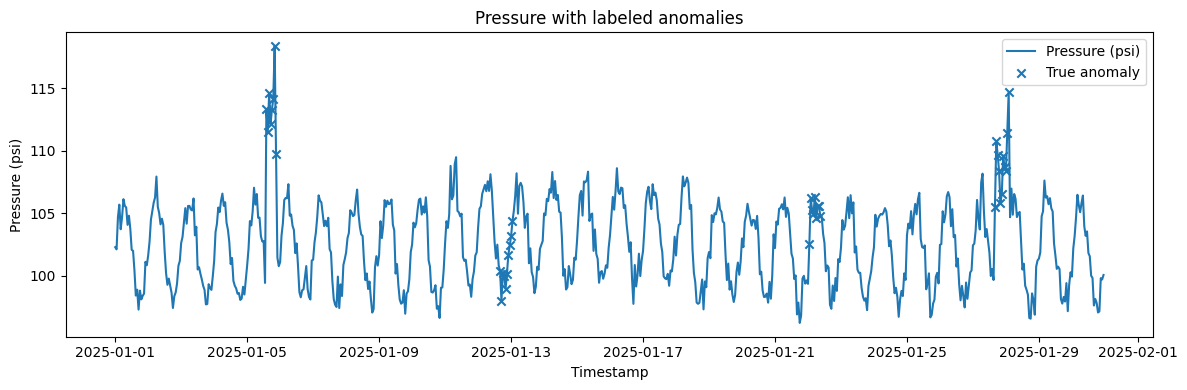

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["pressure_psi"], label="Pressure (psi)")
plt.scatter(df.loc[y == 1, "timestamp"],
            df.loc[y == 1, "pressure_psi"],
            label="True anomaly", marker="x")
plt.title("Pressure with labeled anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Pressure (psi)")
plt.legend()
plt.tight_layout()
plt.show()

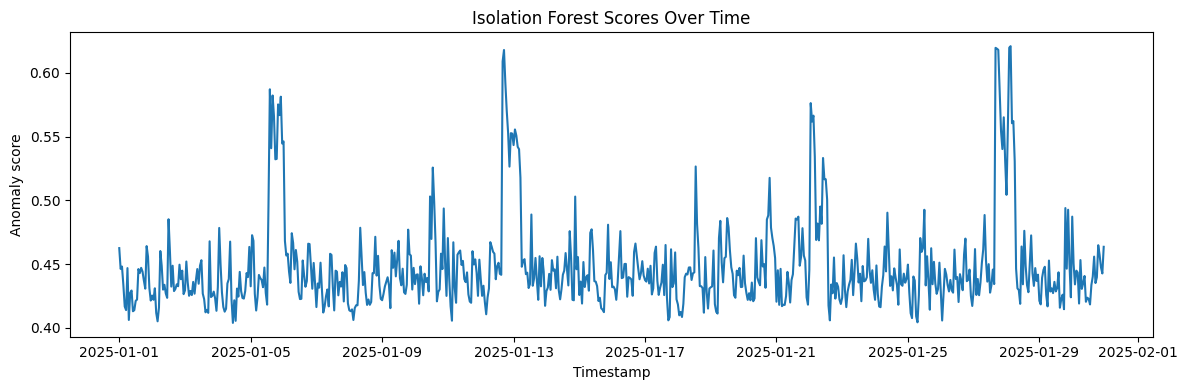

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], iso.scores, label="Isolation Forest anomaly score")
plt.title("Isolation Forest Scores Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly score")
plt.tight_layout()
plt.show()

In [13]:
rf.artifacts["feature_importance"]

,feature,importance
0,pressure_flow_ratio,0.211151
1,temperature_c,0.146457
2,flow_roll_mean_5,0.108626
3,flow_rate_m3h,0.094565
4,temperature_roll_mean_5,0.087593
5,pressure_roll_std_5,0.070433
6,pressure_psi,0.060339
7,temperature_roll_std_5,0.040728
8,pressure_roll_mean_5,0.032921
9,pressure_diff,0.031044


## Notes

- **Isolation Forest** is useful when labels are limited.
- **Random Forest** is included as a supervised benchmark because this synthetic dataset has labels.